<a href="https://colab.research.google.com/github/OlaHPH/assignments/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: APIs, Data Formats, Databases, and EDA

---

## Submission Instructions

Submit only a link to the folder for Assignment 2 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment2.ipynb` or something similar, placed inside the `assignments/assignment2/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Tasks

### Task 0: Course project dataset exploration (2p)


The dataset I would like to use for the project is "Treatment of waste by waste category, hazardousness and waste management operations" from Eurostat.

URL: https://data.europa.eu/data/datasets/8bxb7vunmkpy3c2mnoelw?locale=en and https://ec.europa.eu/eurostat/cache/metadata/en/env_wasgt_esms.htm#shortstat_unitDisseminated

The dataset records the waste treatment operations among European countries within the period from 2004 to 2022 biennialy.
The dataset covers variables including:

*   Geographic (EU member states)
*   Hazardous classification (hazardous, non-hazardous, or both)
*   Time (year recorded)
*   Waste category (46)
*   Waste treatment type (9)
*   Unit of measure (in tones or kilograms per capita)
*   Time frequency (annual)

There are 526405 rows in the dataset.

My goal is to explore how waste treatment operations for different waste categories differ among European states over the time.


In [196]:
#c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect).
#This includes computing summary statistics (e.g. using `.describe()`) and creating at least 2 visualizations of the data. (1p)

import pandas as pd
import requests
import io #wrap the flat strings into a file-like csv format

url = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/env_wastrt?format=SDMX-CSV&compressed=false"

response = requests.get(url)
#print(response.status_code)

df = pd.read_csv(io.StringIO(response.text))
print('Shape:',df.shape)
df.info()

Shape: (526405, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526405 entries, 0 to 526404
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATAFLOW     526405 non-null  object 
 1   LAST UPDATE  526405 non-null  object 
 2   freq         526405 non-null  object 
 3   unit         526405 non-null  object 
 4   hazard       526405 non-null  object 
 5   wst_oper     526405 non-null  object 
 6   waste        526405 non-null  object 
 7   geo          526405 non-null  object 
 8   TIME_PERIOD  526405 non-null  int64  
 9   OBS_VALUE    442634 non-null  float64
 10  OBS_FLAG     82188 non-null   object 
 11  CONF_STATUS  8921 non-null    object 
dtypes: float64(1), int64(1), object(10)
memory usage: 48.2+ MB


In [3]:
df.describe() #exploratory data analysis

,TIME_PERIOD,OBS_VALUE
count,526405.000000,4.426340e+05
mean,2015.074553,1.753130e+06
std,4.834264,3.018986e+07
min,2004.000000,0.000000e+00
25%,2012.000000,0.000000e+00
50%,2016.000000,1.000000e+00
75%,2020.000000,8.150000e+02
max,2022.000000,2.383700e+09


In [60]:
print(df['unit'].value_counts())
print()
print(df['hazard'].value_counts())
print()
print(df['wst_oper'].value_counts())
print()
print(df['waste'].value_counts())
print()
print(df['geo'].value_counts())
print()
print(df['OBS_VALUE'].value_counts())


unit
T         263296
KG_HAB    263109
Name: count, dtype: int64

hazard
HAZ_NHAZ    177453
NHAZ        174595
HAZ         174357
Name: count, dtype: int64

wst_oper
TRT          66088
DSP_L        59708
DSP_L_OTH    59450
DSP_OTH      59368
RCV_R_B      59312
DSP_I        58805
RCV_E        58793
RCV_R        53225
RCV_B        51656
Name: count, dtype: int64

waste
TOTAL          17704
W102           16878
W103           16874
W013           16658
W101           16270
W093           15836
W05            15091
W077           15052
W074           14714
W076           14712
W073           14712
W072           14698
W071           14532
W075           14185
W11            13908
W092           13904
W061           13892
W091           13890
W062           13888
W011           13878
W063           13872
W032           13358
W12B           13348
W08A           13345
W124           13336
W126           13335
TOT_X_MIN      13334
W02A           13330
W128_13        13328
W012           13326


In [197]:
#filtering the data from the dataset
df_clean = df[
    (df['waste'] == 'TOTAL') & # keeping only 'TOTAL' to avoide double counting
    (df['hazard'] == 'HAZ_NHAZ') & # keeping combined 'HAZ_NHAZ' as hazardous and non-hazardous waste total
    (df['wst_oper'] == 'TRT') & # keeping 'TRT' as total waste treatment
    (df['unit'] == 'T') & #keeping only 'T' for unit measured in tonnes
    (~df['geo'].isin(['EU27_2020', 'EU28'])) #dropping EU as a whole, keeping only individual states
].dropna(subset=['OBS_VALUE']).copy() #drop rows where 'OBS_VALUE' is missing value

print('Shape:', df_clean.shape)
print(df_clean.head())

Shape: (333, 12)
                     DATAFLOW        LAST UPDATE freq unit    hazard wst_oper  \
428088  ESTAT:ENV_WASTRT(1.0)  23/09/25 23:00:00    A    T  HAZ_NHAZ      TRT   
428089  ESTAT:ENV_WASTRT(1.0)  23/09/25 23:00:00    A    T  HAZ_NHAZ      TRT   
428090  ESTAT:ENV_WASTRT(1.0)  23/09/25 23:00:00    A    T  HAZ_NHAZ      TRT   
428091  ESTAT:ENV_WASTRT(1.0)  23/09/25 23:00:00    A    T  HAZ_NHAZ      TRT   
428092  ESTAT:ENV_WASTRT(1.0)  23/09/25 23:00:00    A    T  HAZ_NHAZ      TRT   

        waste geo  TIME_PERIOD   OBS_VALUE OBS_FLAG CONF_STATUS  
428088  TOTAL  AL         2014   1228883.0      NaN         NaN  
428089  TOTAL  AL         2022   1476512.0        d         NaN  
428090  TOTAL  AT         2004  51627556.0      NaN         NaN  
428091  TOTAL  AT         2006  47127938.0      NaN         NaN  
428092  TOTAL  AT         2008  48353391.0      NaN         NaN  


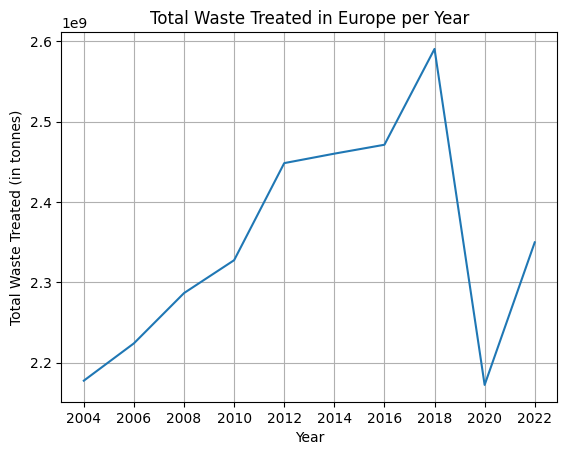

In [175]:
# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#plot1 - total waste treated in Europe over year (2004-2022) in tonnes
yearly_total = df_clean.groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()
sns.lineplot(data=yearly_total, x='TIME_PERIOD', y='OBS_VALUE')
plt.title('Total Waste Treated in Europe per Year')
plt.xlabel('Year')
plt.ylabel('Total Waste Treated (in tonnes)')
plt.xticks(yearly_total['TIME_PERIOD'])
plt.grid(True)
plt.show()

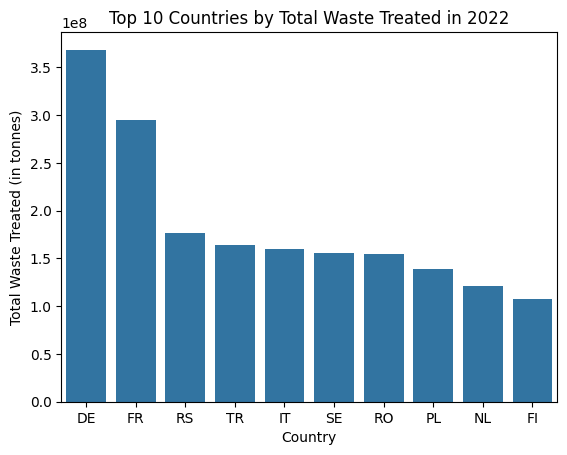

In [104]:
# plot 2 - top 10 European countries by total waste treated in 2022
top10 = (df_clean[df_clean['TIME_PERIOD'] == 2022]
         .sort_values('OBS_VALUE', ascending=False)
         .head(10))

sns.barplot(data=top10, x='geo', y='OBS_VALUE')
plt.title('Top 10 Countries by Total Waste Treated in 2022')
plt.xlabel('Country')
plt.ylabel('Total Waste Treated (in tonnes)')
plt.show()

### Task 1: Setting up an API key and .env file (1p)

Set up an account and get a free-tier API key at [https://marketstack.com/](https://marketstack.com/) (no bank details required).

Store the API key in a `.env` file and load it in your notebook using `python-dotenv`. Print out only the first 5 characters of the key (e.g. `print(api_key[:5] + "...")`) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

**Important:** Do not include the `.env` file in your GitHub repository. Add `.env` to your `.gitignore`. The API key must not be fully visible anywhere in the notebook or repository.

In [39]:
# I am using Google Colab, the API key is added in the Secrets field and called out using

from google.colab import userdata

api_key = userdata.get('Marketstack_API_key')
print(api_key[:5] + "...")

e2125...


### Task 2: Retrieving data from MarketStack (1p)

Use the [MarketStack API](https://docs.apilayer.com/marketstack/docs/api-documentation?utm_source=dashboard&utm_medium=Referral) to investigate how the FAANG stocks performed in March 2026.

In [198]:
#Retrieve End-of-Day (eod) data for 5 stocks Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG) from 01 until 31 March 2026 using MarketStack API.
import requests
import pandas as pd

#load Marketstack API key
from google.colab import userdata
api_key = userdata.get('Marketstack_API_key')

url = 'http://api.marketstack.com/v1/eod'
tickers = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']
stock_data = []

for t in tickers:
  params = {
    'access_key': api_key,
    'symbols': t,
    'date_from': '2026-03-01',
    'date_to': '2026-03-31',
    'limit': 500
  }

  response = requests.get(url, params = params)
  data = response.json()

  if 'data' in data:
    stock_data.extend(data['data'])


In [178]:
#b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.
df_stock = pd.DataFrame(stock_data)
print('Shape:', df_stock.shape)
print()
print(df_stock['symbol'].value_counts())
print()
display(df_stock.head())

Shape: (110, 15)

symbol
META    22
AAPL    22
AMZN    22
NFLX    22
GOOG    22
Name: count, dtype: int64



,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


In [81]:
#c 1/2) Compute summary statistics for the closing prices grouped by stock.
closing = df_stock.groupby('symbol')['close'].describe()
print(closing)

        count        mean        std     min       25%      50%       75%  \
symbol                                                                      
AAPL     22.0  254.906364   5.510351  246.63  250.4625  253.340  260.1875   
AMZN     22.0  209.995000   4.643217  199.34  207.8200  209.700  213.0700   
GOOG     22.0  297.980455  10.928636  273.14  291.7675  302.335  305.9400   
META     22.0  614.990909  41.309579  525.72  593.9675  619.170  652.0175   
NFLX     22.0   95.076364   2.512109   90.92   93.3350   94.795   97.0525   

           max  
symbol          
AAPL    264.72  
AMZN    218.94  
GOOG    309.41  
META    667.73  
NFLX     99.17  


In [192]:
#c2/2) Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day).
#Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.
df_stock['date'] = pd.to_datetime(df_stock['date']).dt.date #convert date column to datetime
df_stock = df_stock.sort_values(['symbol','date']) #sort date column by ticker and dates

first_day_price = df_stock.groupby('symbol')['close'].first() #get the first trading day's closing price
last_day_price = df_stock.groupby('symbol')['close'].last() #get the last trading day's closing price

#calculate the percentage change
percentage_change = (((last_day_price-first_day_price)/first_day_price)*100).round(2)
print('Return percentage over the month:')
print(percentage_change)

print(f'The best performed FAANG stock in March 2026 is {percentage_change.idxmax()} with {percentage_change.max()}%.')
print(f'The worst performed FAANG stock in March 2026 is {percentage_change.idxmin()} with {percentage_change.min()}%.')

Return percentage over the month:
symbol
AAPL    -4.13
AMZN    -0.06
GOOG    -6.37
META   -12.46
NFLX    -0.97
Name: close, dtype: float64
The best performed FAANG stock in March 2026 is AMZN with -0.06%.
The worst performed FAANG stock in March 2026 is META with -12.46%.


### Task 3: Visualizing stock data (1p)

Using the data from Task 2, create 3 visualizations using seaborn.

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

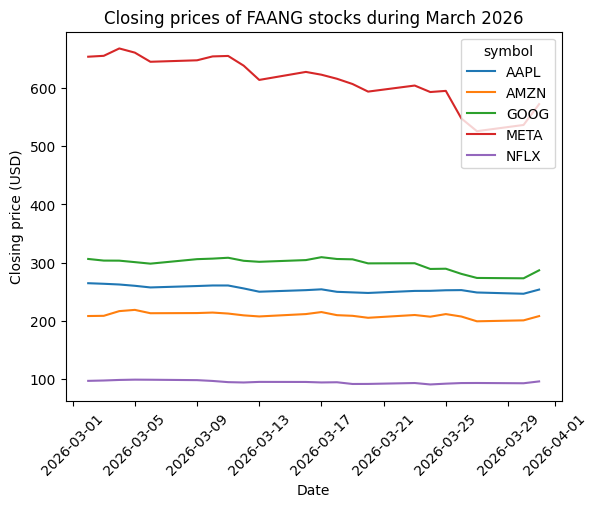

In [191]:
#A line chart showing the closing price of each stock over time during March 2026.
#The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.
sns.lineplot(data=df_stock, x='date', y='close', hue='symbol')
plt.title('Closing prices of FAANG stocks during March 2026')
plt.xlabel('Date')
plt.ylabel('Closing price (USD)')
plt.xticks(rotation=45)
plt.show()

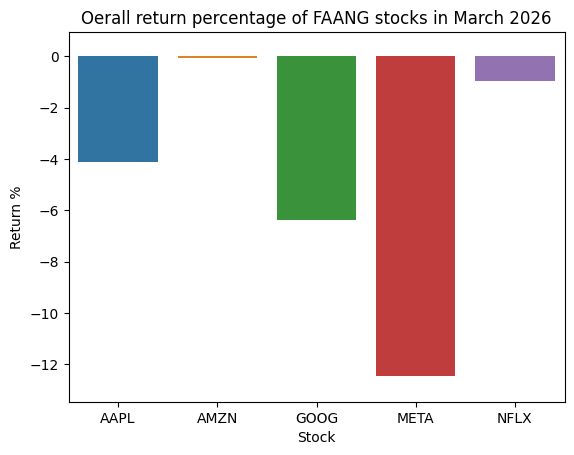

In [190]:
#b) A bar plot showing the overall return percentage for each stock in March 2026.
sns.barplot(x=percentage_change.index, y = percentage_change.values, hue = percentage_change.index, legend = False)
plt.title('Oerall return percentage of FAANG stocks in March 2026')
plt.xlabel('Stock')
plt.ylabel('Return %')
plt.ylim(percentage_change.min()-1, percentage_change.max()+1)
plt.show()

Text(0.5, 1.0, 'Daily trading volume of FAANG stocks in March 2026')

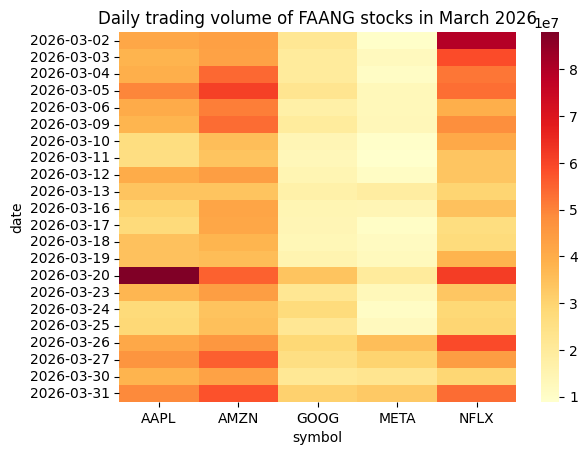

In [193]:
#c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).
pivot = df_stock.pivot(index = 'date', columns = 'symbol', values = 'volume')
sns.heatmap(pivot, fmt='.0f', cmap="YlOrRd")
plt.title('Daily trading volume of FAANG stocks in March 2026')

### Task 4: Exporting and importing data (1p)


In [194]:
#a) Export the JSON data retrieved in Task 2a as a JSON file stockdata.json into a subfolder called exports.
import os
import json
os.makedirs('exports', exist_ok=True)

with open('exports/stockdata.json', 'w') as f:
  json.dump(stock_data, f, indent=2)

#b) Export the DataFrame from Task 2b as a CSV file stockdata.csv into the same exports subfolder.
df_stock.to_csv('exports/stockdata.csv', index=False)

#c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.
with open('exports/stockdata.json', 'r') as f:
    loaded_json = json.load(f)
df_from_json = pd.DataFrame(loaded_json)
display(df_from_json.head())

df_from_csv = pd.read_csv('exports/stockdata.csv')
display(df_from_csv.head())

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,549.98,573.69,546.77,572.13,32809500.0,573.6900,546.77,572.13,549.98,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
1,536.38,539.55,528.54,536.38,22758800.0,539.5500,528.54,536.38,536.38,22795203.0,1.0,0.0,META,ARCX,2026-03-30T00:00:00+0000
2,540.10,543.60,520.26,525.72,29980300.0,543.5999,520.26,525.72,540.10,30133010.0,1.0,0.0,META,ARCX,2026-03-27T00:00:00+0000
3,582.49,583.00,543.35,547.54,35664700.0,583.0000,543.35,547.54,582.49,35780131.0,1.0,0.0,META,ARCX,2026-03-26T00:00:00+0000
4,598.74,603.62,593.40,594.89,12161179.0,603.6700,593.40,594.89,598.74,12585031.0,1.0,0.0,META,ARCX,2026-03-25T00:00:00+0000


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,AAPL,XNAS,2026-03-02
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,AAPL,XNAS,2026-03-03
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,AAPL,XNAS,2026-03-04
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,AAPL,XNAS,2026-03-05
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,AAPL,XNAS,2026-03-06


## Statement of use of AI

AI is used in concept, and code failure explanation, and alternative solutions. The code choice and assignment solutions were conducted based on my own understanding.